In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import pandas as pd
from IPython.display import HTML, display

# Ajuste para a pasta onde estão os .parquet no Drive:
PASTA = '/content/drive/MyDrive/lkml5w'

iio_parquet = pd.read_parquet(f'{PASTA}/iio-regex-classified-status.parquet')
total_threads_before_filtering = 16291
total_threads_after_filtering  = 429
total_threads_duplication      = 121
total_threads_redundancy       = 132

# --- Cartões de números (KPI cards) ------------------------------------------
cards = [
    ("Threads antes do filtro", total_threads_before_filtering, "#495057", ""),
    ("Threads após o filtro (regex)", total_threads_after_filtering, "#1f77b4",
      f"{total_threads_after_filtering/total_threads_before_filtering*100:.1f}% do total"),
    ("Threads de DUPLICAÇÃO", total_threads_duplication, "#e6733c",
      f"{total_threads_duplication/total_threads_after_filtering*100:.1f}% das filtradas"),
    ("Threads de REDUNDÂNCIA", total_threads_redundancy, "#2ca02c",
      f"{total_threads_redundancy/total_threads_after_filtering*100:.1f}% das filtradas"),
]

def card_html(titulo, valor, cor, sub):
    subtitulo = (f'<div style="font-size:14px;color:#6c757d;margin-top:6px;">{sub}</div>'
                  if sub else '')
    return f'''
    <div style="flex:1 1 200px;min-width:200px;background:#ffffff;
                border-radius:16px;padding:24px 20px;
                box-shadow:0 2px 10px rgba(0,0,0,0.08);
                border-top:6px solid {cor};text-align:center;">
      <div style="font-size:15px;font-weight:600;color:#495057;
                  text-transform:uppercase;letter-spacing:.5px;">{titulo}</div>
      <div style="font-size:52px;font-weight:800;color:{cor};
                  line-height:1.1;margin-top:10px;">{valor:,}</div>
      {subtitulo}
    </div>'''

html = f'''
<div style="font-family:'DejaVu Sans',Arial,sans-serif;max-width:1000px;margin:8px auto;">
  <h2 style="text-align:center;color:#212529;margin-bottom:4px;">
      Threads de código duplicado — LKML / IIO</h2>
  <p style="text-align:center;color:#6c757d;margin-top:0;">
      Do total inicial até a classificação por LLM</p>
  <div style="display:flex;flex-wrap:wrap;gap:18px;justify-content:center;
              margin-top:18px;">
      {''.join(card_html(t, v, c, s) for t, v, c, s in cards)}
  </div>
</div>'''

display(HTML(html))

In [ ]:
import re
from IPython.display import HTML, display

# --- Threads cujo AUTOR (quem enviou a submissão original) tem e-mail USP -----
USP_EMAIL_RE = re.compile(r'[\w.+-]+@(?:[\w.-]+\.)?usp\.br\b', re.IGNORECASE)

total_threads = iio_parquet['_thread_id'].nunique()          # 429

# autor = remetentes das mensagens de submissão
submissoes = iio_parquet[iio_parquet['has_response_tag'] == False]
autor_e_usp = (submissoes.groupby('_thread_id')['from']
                .apply(lambda s: s.astype(str).str.contains(USP_EMAIL_RE).any()))

threads_autor_usp = int(autor_e_usp.sum())                    # 10
pct = threads_autor_usp / total_threads * 100

html = f'''
<div style="font-family:'DejaVu Sans',Arial,sans-serif;max-width:560px;margin:8px auto;">
  <h2 style="text-align:center;color:#212529;margin-bottom:4px;">
      Threads com autor da USP</h2>
  <p style="text-align:center;color:#6c757d;margin-top:0;">
      Autor = quem enviou o patch original (e-mail @usp.br / @ime.usp.br)</p>
  <div style="display:flex;flex-wrap:wrap;gap:18px;justify-content:center;margin-top:18px;">
      <div style="flex:1 1 200px;min-width:200px;background:#fff;border-radius:16px;
                  padding:24px 20px;box-shadow:0 2px 10px rgba(0,0,0,0.08);
                  border-top:6px solid #9467bd;text-align:center;">
        <div style="font-size:15px;font-weight:600;color:#495057;
                    text-transform:uppercase;letter-spacing:.5px;">Threads com autor USP</div>
        <div style="font-size:52px;font-weight:800;color:#9467bd;
                    line-height:1.1;margin-top:10px;">{threads_autor_usp}</div>
        <div style="font-size:14px;color:#6c757d;margin-top:6px;">de {total_threads} threads ({pct:.1f}%)</div>
      </div>
  </div>
</div>'''

display(HTML(html))

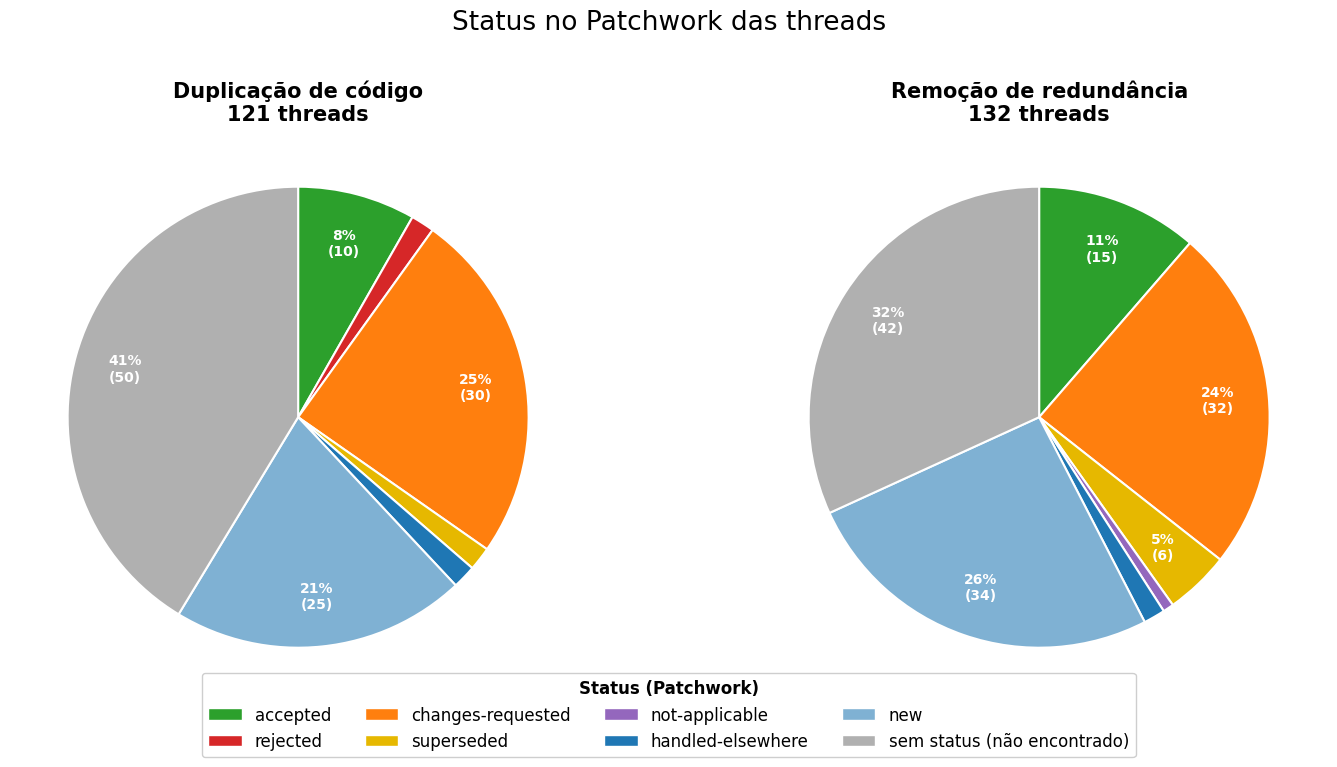

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- 0) Estilo geral
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'figure.titlesize': 19,
})

# --- 1) Reduz cada thread a UM status do Patchwork
PRIORIDADE = ['accepted', 'mainlined', 'rejected', 'changes-requested',
              'superseded', 'not-applicable', 'handled-elsewhere', 'new']

def status_da_thread(grupo):
    presentes = [s for s in grupo['accepted'] if s]      # descarta os vazios
    for st in PRIORIDADE:
        if st in presentes:
            return st
    return 'sem status (não encontrado)'

por_thread = (
    iio_parquet
    .groupby('_thread_id')[['duplication_classification', 'accepted']]
    .apply(lambda g: pd.Series({
        'classificacao': g['duplication_classification'].iloc[0],
        'status': status_da_thread(g),
    }))
    .reset_index()
)

# --- 2) -
ORDEM_STATUS = PRIORIDADE + ['sem status (não encontrado)']
PALETA = {
    'accepted':                    '#2ca02c',  # verde  - aceito
    'mainlined':                   '#17a2a2',  # teal   - mainline
    'rejected':                    '#d62728',  # vermelho- rejeitado
    'changes-requested':           '#ff7f0e',  # laranja - pediu mudanças
    'superseded':                  '#e6b800',  # dourado - substituído
    'not-applicable':              '#9467bd',  # roxo    - não se aplica
    'handled-elsewhere':           '#1f77b4',  # azul    - tratado alhures
    'new':                         '#7fb1d3',  # azul claro - novo
    'sem status (não encontrado)': '#b0b0b0',  # cinza   - sem info
}

def make_autopct(total):
    def _fmt(p):
        if p < 3:                 # esconde rótulo de fatia muito pequena
            return ''
        return f'{p:.0f}%\n({round(p * total / 100)})'
    return _fmt

# --- 3) Dois gráficos de pizza lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Status no Patchwork das threads', y=1.02)

for ax, (rotulo, titulo) in zip(
        axes,
        [('CODE_DUPLICATION',   'Duplicação de código'),
          ('REDUNDANCY_REMOVAL', 'Remoção de redundância')]):
    contagem = (por_thread.loc[por_thread['classificacao'] == rotulo, 'status']
                .value_counts())
    contagem = contagem.reindex([s for s in ORDEM_STATUS if s in contagem.index])
    ax.pie(
        contagem,
        colors=[PALETA[s] for s in contagem.index],
        startangle=90,
        counterclock=False,
        autopct=make_autopct(contagem.sum()),
        pctdistance=0.78,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'color': 'white', 'fontweight': 'bold', 'fontsize': 10},
    )
    ax.set_title(f'{titulo}\n{contagem.sum()} threads')

# --- 4) Legenda única (status -> cor)
_plotados = por_thread['classificacao'].isin(['CODE_DUPLICATION', 'REDUNDANCY_REMOVAL'])
presentes = [s for s in ORDEM_STATUS
              if (por_thread.loc[_plotados, 'status'] == s).any()]
handles = [Patch(facecolor=PALETA[s], edgecolor='white', label=s) for s in presentes]
leg = fig.legend(handles=handles, title='Status (Patchwork)',
                  loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06),
                  frameon=True, fancybox=True, framealpha=0.95)
leg.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display

# --- Quem RESPONDE às threads de duplicação/redundância SEM ser o autor ------
# "resposta" = has_response_tag == True (assunto "Re:")
# "autor da thread" = remetente das mensagens de submissão (não-resposta) da thread

def nome_remetente(v):
    nome = str(v).split('<')[0].strip().strip('"')
    return nome if nome else str(v)      # sem nome -> usa o valor cru (e-mail)

alvo = iio_parquet[iio_parquet['duplication_classification']
                    .isin(['CODE_DUPLICATION', 'REDUNDANCY_REMOVAL'])].copy()
alvo['mantenedor'] = alvo['from'].apply(nome_remetente)

# nome do autor de cada thread (quem enviou a submissão original)
autores_por_thread = (alvo[alvo['has_response_tag'] == False]
                      .groupby('_thread_id')['mantenedor'].agg(set))

# respostas, excluindo aquelas em que o remetente é o próprio autor da thread
respostas = alvo[alvo['has_response_tag'] == True].copy()
eh_autor = respostas.apply(
    lambda r: r['mantenedor'] in autores_por_thread.get(r['_thread_id'], set()),
    axis=1)
respostas = respostas[~eh_autor]

def tabela_resumo(sub, titulo, n=10):
    tab = (sub.groupby('mantenedor')
              .agg(threads=('_thread_id', 'nunique'),   # em quantas threads aparece
                    respostas=('message_id', 'count'))    # nº total de respostas
              .sort_values(['threads', 'respostas'], ascending=False)
              .head(n)
              .reset_index())
    tab.insert(0, 'Posição', range(1, len(tab) + 1))
    tab = tab.rename(columns={
        'mantenedor': 'Mantenedor',
        'threads':    'Threads (nº)',
        'respostas':  'Respostas (nº)',
    })

    legenda = (f'{titulo} — respostas: {len(sub)} | '
                f'pessoas distintas: {sub["mantenedor"].nunique()}')

    estilo = (
        tab.style
            .hide(axis='index')                                   # some com o índice
            .set_caption(legenda)                                 # título da tabela
            .background_gradient(subset=['Threads (nº)', 'Respostas (nº)'],
                                cmap='Blues')                     # destaque por valor
            .set_properties(**{'text-align': 'center'})
            .set_properties(subset=['Mantenedor'], **{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'caption',
                'props': [('font-size', '15px'), ('font-weight', 'bold'),
                          ('text-align', 'left'), ('padding', '6px 0')]},
                {'selector': 'th',
                'props': [('background-color', '#4C79A6'), ('color', 'white'),
                          ('text-align', 'center'), ('padding', '6px 10px')]},
                {'selector': 'td', 'props': [('padding', '5px 10px')]},
            ])
    )
    display(estilo)

tabela_resumo(respostas[respostas['duplication_classification'] == 'CODE_DUPLICATION'],
              'DUPLICAÇÃO de código')
tabela_resumo(respostas[respostas['duplication_classification'] == 'REDUNDANCY_REMOVAL'],
              'REMOÇÃO de redundância')
tabela_resumo(respostas, 'DUPLICAÇÃO + REDUNDÂNCIA (geral)')

Posição,Mantenedor,Threads (nº),Respostas (nº)
1,Jonathan Cameron,84,356
2,Andy Shevchenko,24,99
3,Lars-Peter Clausen,12,38
4,Krzysztof Kozlowski,9,22
5,Greg KH,8,13
6,David Lechner,7,17
7,Daniel Baluta,6,12
8,Rob Herring,6,9
9,Peter Meerwald,6,7
10,Lee Jones,4,11


Posição,Mantenedor,Threads (nº),Respostas (nº)
1,Jonathan Cameron,99,497
2,Andy Shevchenko,20,93
3,Nuno Sá,13,44
4,David Lechner,11,39
5,Greg KH,11,16
6,Rob Herring,9,14
7,Uwe Kleine-König,6,20
8,Lars-Peter Clausen,6,17
9,Conor Dooley,6,14
10,Rob Herring (Arm),6,6


Posição,Mantenedor,Threads (nº),Respostas (nº)
1,Jonathan Cameron,183,853
2,Andy Shevchenko,44,192
3,Greg KH,19,29
4,David Lechner,18,56
5,Lars-Peter Clausen,18,55
6,Nuno Sá,17,54
7,Rob Herring,15,23
8,Krzysztof Kozlowski,14,30
9,Conor Dooley,8,17
10,Peter Meerwald,8,9


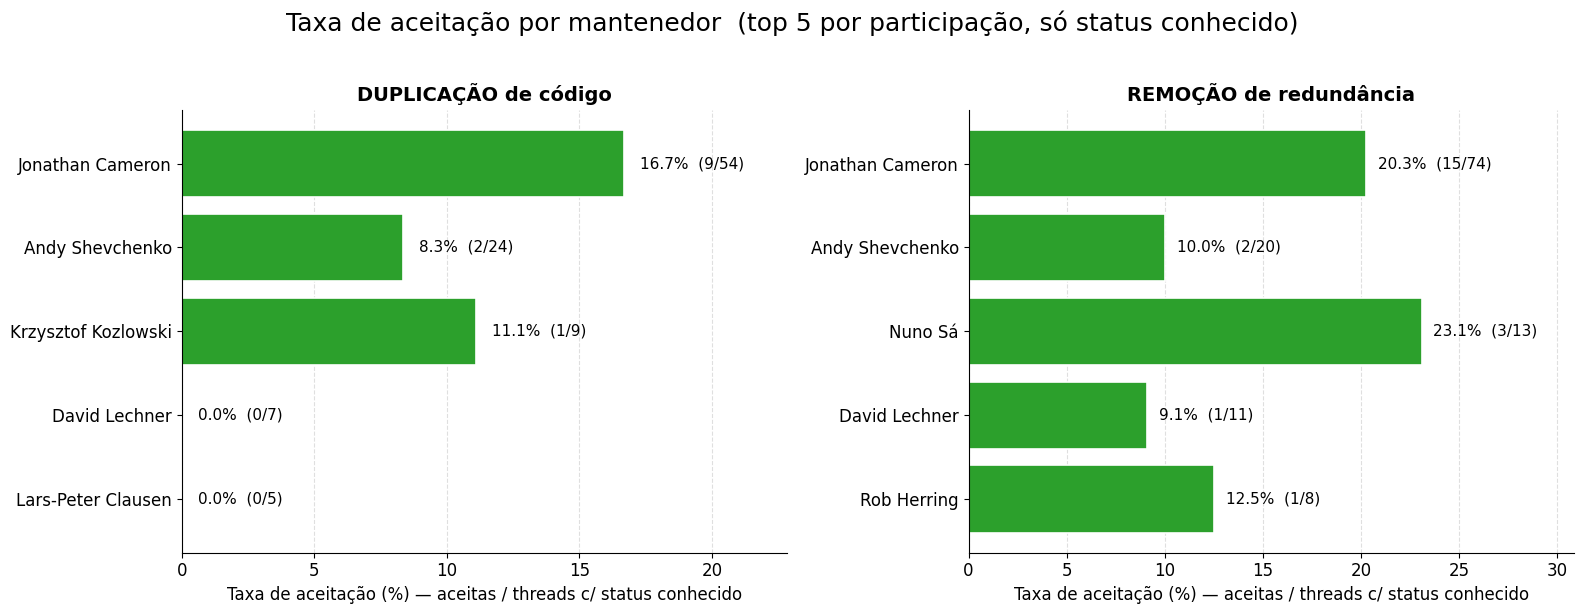

In [ ]:
import matplotlib.pyplot as plt

# --- 0) Estilo
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 18,
})
COR_BARRA = '#2ca02c'

# --- 1) Status colapsado por thread
PRIORIDADE = ['accepted', 'mainlined', 'rejected', 'changes-requested',
              'superseded', 'not-applicable', 'handled-elsewhere', 'new']

def status_da_thread(serie_accepted):
    presentes = [s for s in serie_accepted if s]
    for st in PRIORIDADE:
        if st in presentes:
            return st
    return ''

def nome_remetente(v):
    nome = str(v).split('<')[0].strip().strip('"')
    return nome if nome else str(v)

alvo = iio_parquet[iio_parquet['duplication_classification']
                    .isin(['CODE_DUPLICATION', 'REDUNDANCY_REMOVAL'])].copy()
alvo['mantenedor'] = alvo['from'].apply(nome_remetente)

status_thread = alvo.groupby('_thread_id')['accepted'].apply(status_da_thread)
threads_aceitas    = set(status_thread[status_thread.isin(['accepted', 'mainlined'])].index)
threads_conhecidas = set(status_thread[status_thread != ''].index)   # exclui "sem status"

# rótulo (dup/redundância) de cada thread
classe_por_thread = alvo.groupby('_thread_id')['duplication_classification'].first()

# --- 2) Respostas de NÃO-autores
autores_por_thread = (alvo[alvo['has_response_tag'] == False]
                      .groupby('_thread_id')['mantenedor'].agg(set))
respostas = alvo[alvo['has_response_tag'] == True].copy()
respostas = respostas[~respostas.apply(
    lambda r: r['mantenedor'] in autores_por_thread.get(r['_thread_id'], set()),
    axis=1)]

threads_por_mant = respostas.groupby('mantenedor')['_thread_id'].agg(set)

# --- 3) Top 5 + taxa de aceitação, calculados por classificação
def top5_por_classe(label):
    threads_classe = set(classe_por_thread[classe_por_thread == label].index)
    res = pd.DataFrame({
        'participou': threads_por_mant.apply(
            lambda ths: len(ths & threads_conhecidas & threads_classe)),
        'aceitas': threads_por_mant.apply(
            lambda ths: len(ths & threads_aceitas & threads_classe)),
    })
    res = res[res['participou'] > 0]                  # evita divisão por zero
    res['taxa'] = res['aceitas'] / res['participou']
    return res.sort_values('participou', ascending=False).head(5).iloc[::-1]

# --- 4) Dois gráficos: duplicação e redundância
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Taxa de aceitação por mantenedor  (top 5 por participação, só status conhecido)',
              y=1.02)

for ax, (label, titulo) in zip(
        axes,
        [('CODE_DUPLICATION',   'DUPLICAÇÃO de código'),
          ('REDUNDANCY_REMOVAL', 'REMOÇÃO de redundância')]):
    top5 = top5_por_classe(label)
    barras = ax.barh(top5.index, top5['taxa'] * 100,
                      color=COR_BARRA, edgecolor='white', linewidth=1.2)
    for barra, (_, linha) in zip(barras, top5.iterrows()):
        ax.text(barra.get_width() + 0.6, barra.get_y() + barra.get_height() / 2,
                f"{linha['taxa']*100:.1f}%  ({int(linha['aceitas'])}/{int(linha['participou'])})",
                va='center', fontsize=11)
    ax.set_xlabel('Taxa de aceitação (%) — aceitas / threads c/ status conhecido')
    ax.set_title(titulo)
    ax.set_xlim(0, max(top5['taxa'] * 100) * 1.25 + 2)
    ax.spines[['top', 'right']].set_visible(False)        # visual mais limpo
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

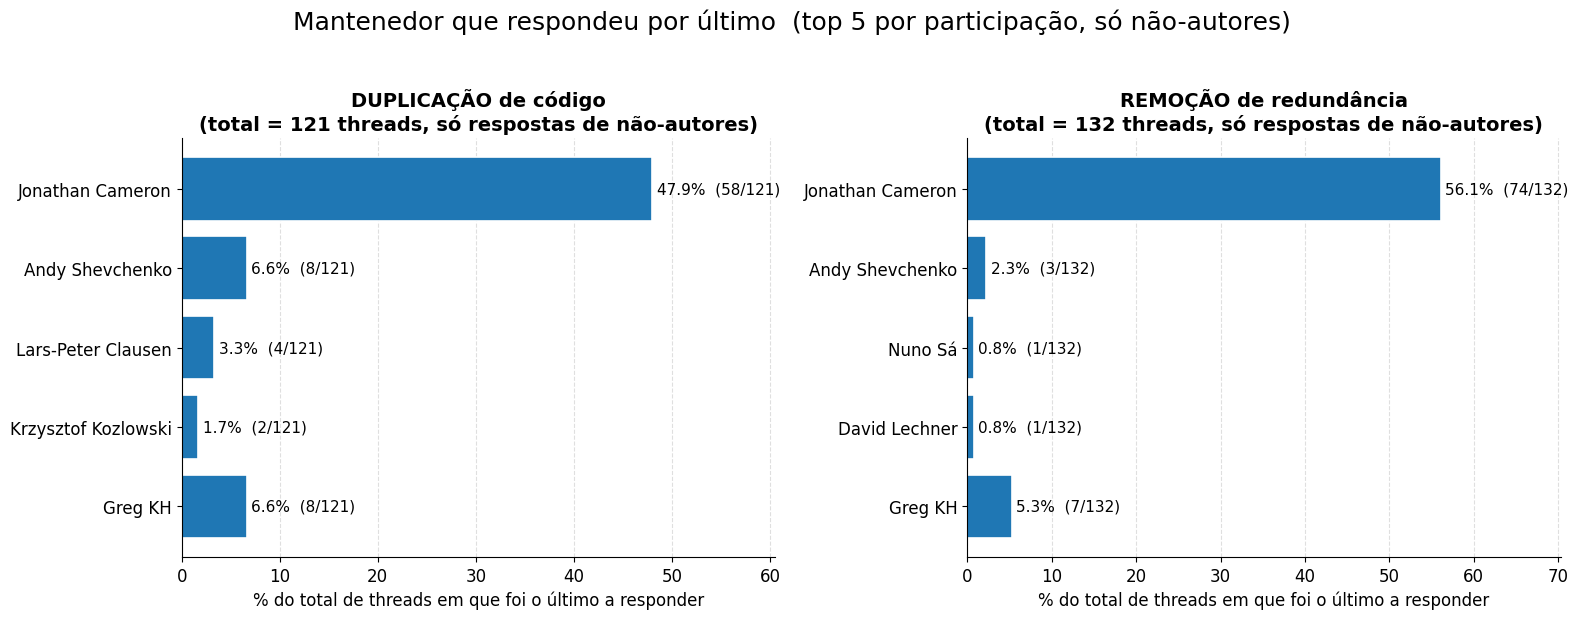

In [ ]:
import matplotlib.pyplot as plt

# --- 0) Estilo
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 18,
})
COR_BARRA = '#1f77b4'

def nome_remetente(v):
    nome = str(v).split('<')[0].strip().strip('"')
    return nome if nome else str(v)

alvo = iio_parquet[iio_parquet['duplication_classification']
                    .isin(['CODE_DUPLICATION', 'REDUNDANCY_REMOVAL'])].copy()
alvo['mantenedor'] = alvo['from'].apply(nome_remetente)

# respostas de NÃO-autores (calculadas uma vez, sobre as duas categorias)
autores_por_thread = (alvo[alvo['has_response_tag'] == False]
                      .groupby('_thread_id')['mantenedor'].agg(set))
respostas = alvo[alvo['has_response_tag'] == True].copy()
respostas = respostas[~respostas.apply(
    lambda r: r['mantenedor'] in autores_por_thread.get(r['_thread_id'], set()),
    axis=1)]
respostas = respostas.sort_values('date')

# --- calcula, POR classificação, o último a responder e o top 5
def dados_por_classe(label):
    sub = respostas[respostas['duplication_classification'] == label]
    total_threads = alvo.loc[alvo['duplication_classification'] == label,
                              '_thread_id'].nunique()
    # último não-autor a responder cada thread (maior data)
    cont_ultimo = sub.groupby('_thread_id').tail(1)['mantenedor'].value_counts()
    # top 5 mais frequentes (por nº de threads em que participaram)
    top5 = list(sub.groupby('mantenedor')['_thread_id'].nunique()
                .sort_values(ascending=False).head(5).index)
    dados = (pd.DataFrame({'n_ultimo': [int(cont_ultimo.get(m, 0)) for m in top5]},
                          index=top5)
              .assign(pct=lambda d: d['n_ultimo'] / total_threads * 100)
              .iloc[::-1])   # maior no topo do gráfico
    return dados, total_threads

# --- dois gráficos: duplicação e redundância
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mantenedor que respondeu por último  (top 5 por participação, só não-autores)',
              y=1.03)

for ax, (label, titulo) in zip(
        axes,
        [('CODE_DUPLICATION',   'DUPLICAÇÃO de código'),
          ('REDUNDANCY_REMOVAL', 'REMOÇÃO de redundância')]):
    dados, total_threads = dados_por_classe(label)
    barras = ax.barh(dados.index, dados['pct'],
                      color=COR_BARRA, edgecolor='white', linewidth=1.2)
    for barra, (_, linha) in zip(barras, dados.iterrows()):
        ax.text(barra.get_width() + 0.5, barra.get_y() + barra.get_height() / 2,
                f"{linha['pct']:.1f}%  ({int(linha['n_ultimo'])}/{total_threads})",
                va='center', fontsize=11)
    ax.set_xlabel('% do total de threads em que foi o último a responder')
    ax.set_title(f'{titulo}\n(total = {total_threads} threads, só respostas de não-autores)')
    ax.set_xlim(0, max(dados['pct']) * 1.2 + 3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

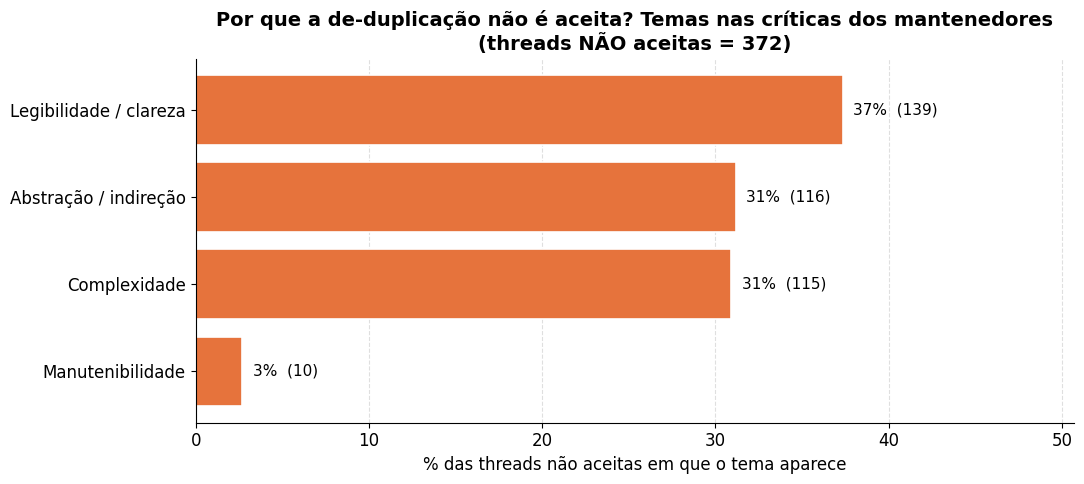

Exemplos (respostas de mantenedores em threads não aceitas):

  • but once it is doing that much, what is te point of the following? You will save a few repeated lines, but at the cost of driver readability.
  • However this should be constrained by the need to maintain readability of the code.
  • In this particular case (just the buffer filling function not the rest which looks pretty good to me!) I think we loose clarity to save few lines.
  • Blank line here would improve readability.
  • I don't think this improves readability.
  • However, the question arises on whether it makes sense to get rid of that in the driver and make it harder to read with the datasheet.
  • #define AD4130_ADC_CTRL_REG #define AD4130_ADC_CTRL_BIPOLAR_MASK Note I quite like the subtle indenting to make it easier to read these definitions as well.
  • return ad7779_spi_write(st, AD7779_REG_CH_OFFSET_LOWER_BYTE(channel), calibbias[2]); etc as it'll shorted the code a little bit for no significant loss of re

In [ ]:
import re
import matplotlib.pyplot as plt

PRIORIDADE = ['accepted', 'mainlined', 'rejected', 'changes-requested',
              'superseded', 'not-applicable', 'handled-elsewhere', 'new']

def status_da_thread(serie_accepted):
    presentes = [s for s in serie_accepted if s]
    for st in PRIORIDADE:
        if st in presentes:
            return st
    return ''

def nome_remetente(v):
    nome = str(v).split('<')[0].strip().strip('"')
    return nome if nome else str(v)

status_thread = iio_parquet.groupby('_thread_id')['accepted'].apply(status_da_thread)
aceitas = set(status_thread[status_thread.isin(['accepted', 'mainlined'])].index)
nao_aceitas = set(status_thread.index) - aceitas

base = iio_parquet.copy()
base['mantenedor'] = base['from'].apply(nome_remetente)
autores_por_thread = (base[base['has_response_tag'] == False]
                      .groupby('_thread_id')['mantenedor'].agg(set))

resp = base[(base['has_response_tag'] == True)
            & (base['_thread_id'].isin(nao_aceitas))].copy()
resp = resp[~resp.apply(
    lambda r: r['mantenedor'] in autores_por_thread.get(r['_thread_id'], set()), axis=1)]
resp = resp[~resp['from'].astype(str).str.contains('bot|lkp|robot', case=False)]

def limpar(texto):
    linhas = []
    for ln in str(texto).splitlines():
        s = ln.strip()
        if not s or s.startswith('>'):
            continue
        if re.fullmatch(r'[A-Za-z0-9+/=]{30,}', s):   # base64
            continue
        if len(s) > 45 and ' ' not in s:              # blob/código
            continue
        linhas.append(s)
    return ' '.join(linhas)

resp['txt'] = resp['raw_body'].apply(limpar)
total = resp['_thread_id'].nunique()

# quatro temas
TEMAS = {
    'Legibilidade / clareza': ['readab', 'readable', 'easier to read', 'harder to read',
                                'hard to read', 'hard to follow', 'clarity', 'clearer',
                                'obfuscat', 'obscure', 'confus'],
    'Abstração / indireção':  ['abstraction', 'indirection', 'wrapper', 'helper', 'macro'],
    'Complexidade':           ['complex', 'complicat', 'convolut', 'simpler', 'simplif',
                                'overengineer', 'over-engineer'],
    'Manutenibilidade':       ['maintainab', 'maintenance'],
}

dados = []
for tema, kws in TEMAS.items():
    pat = re.compile('|'.join(kws), re.IGNORECASE)
    n_threads = resp.loc[resp['txt'].str.contains(pat), '_thread_id'].nunique()
    dados.append((tema, n_threads, n_threads / total * 100))
res = pd.DataFrame(dados, columns=['tema', 'threads', 'pct']).sort_values('threads')

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12,
                      'axes.titleweight': 'bold'})
fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.barh(res['tema'], res['pct'], color='#e6733c',
                  edgecolor='white', linewidth=1.2)
for barra, (_, r) in zip(barras, res.iterrows()):
    ax.text(barra.get_width() + 0.6, barra.get_y() + barra.get_height() / 2,
            f"{r['pct']:.0f}%  ({int(r['threads'])})", va='center', fontsize=11)
ax.set_xlabel('% das threads não aceitas em que o tema aparece')
ax.set_title(f'Por que a de-duplicação não é aceita? Temas nas críticas dos mantenedores\n'
              f'(threads NÃO aceitas = {total})')
ax.set_xlim(0, max(res['pct']) * 1.25 + 4)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

frase = re.compile(r'[^.]*\b(readab|readable|easier to read|harder to read|'
                    r'less readable|more readable|clarity|obfuscat)[^.]*\.', re.IGNORECASE)
print('Exemplos (respostas de mantenedores em threads não aceitas):\n')
vistos, n = set(), 0
for t in resp['txt']:
    for m in frase.finditer(t):
        frag = ' '.join(m.group(0).split())
        if 25 < len(frag) < 170 and frag not in vistos:
            vistos.add(frag)
            print(f'  • {frag}')
            n += 1
    if n >= 12:
        break

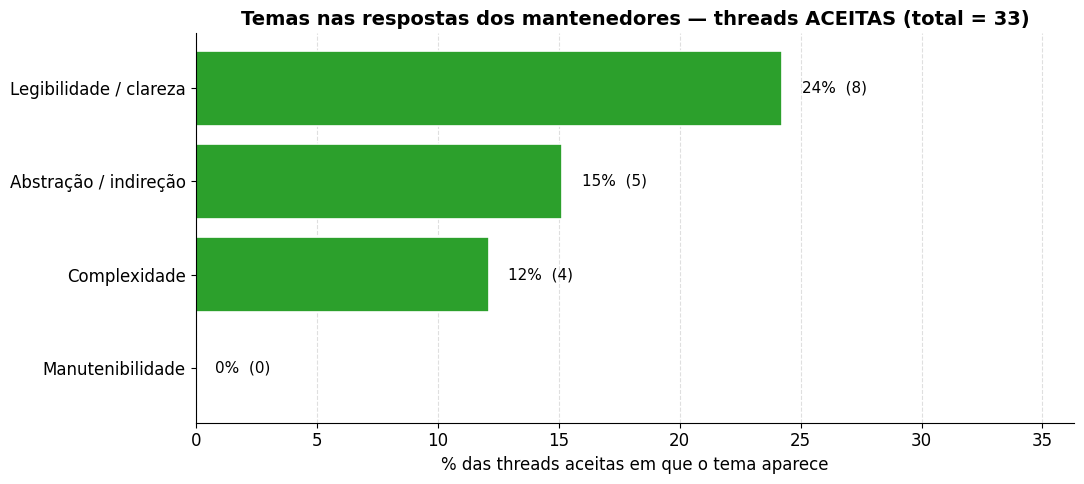

Exemplos (respostas de mantenedores em threads aceitas):

  • I rewrapped a bunch of places where adding line breaks kept lines under 80 chars without affecting the readability.
  • With the above switch that returns on every case, this makes code less readable.
  • This sort of forcing tends to just lead to code churn as further changes turn up over time and doesn't really help readability, particularly in this order.
  • I changed this to { 0x00, 80000 } as I think it helps readability to have them all aligned Spaces added to all entries.
  • This doesn't greatly affect readability and the code ends up a bit shorter.
  • Secondly why a fix at all? Looks like a readability improvement but not something we'd backport.
  • So choose which ever looks most readable in situ.


In [ ]:
import re
import matplotlib.pyplot as plt

PRIORIDADE = ['accepted', 'mainlined', 'rejected', 'changes-requested',
              'superseded', 'not-applicable', 'handled-elsewhere', 'new']

def status_da_thread(serie_accepted):
    presentes = [s for s in serie_accepted if s]
    for st in PRIORIDADE:
        if st in presentes:
            return st
    return ''

def nome_remetente(v):
    nome = str(v).split('<')[0].strip().strip('"')
    return nome if nome else str(v)

status_thread = iio_parquet.groupby('_thread_id')['accepted'].apply(status_da_thread)
aceitas = set(status_thread[status_thread.isin(['accepted', 'mainlined'])].index)

base = iio_parquet.copy()
base['mantenedor'] = base['from'].apply(nome_remetente)
autores_por_thread = (base[base['has_response_tag'] == False]
                      .groupby('_thread_id')['mantenedor'].agg(set))

resp = base[(base['has_response_tag'] == True)
            & (base['_thread_id'].isin(aceitas))].copy()
resp = resp[~resp.apply(
    lambda r: r['mantenedor'] in autores_por_thread.get(r['_thread_id'], set()), axis=1)]
resp = resp[~resp['from'].astype(str).str.contains('bot|lkp|robot', case=False)]

def limpar(texto):
    linhas = []
    for ln in str(texto).splitlines():
        s = ln.strip()
        if not s or s.startswith('>'):
            continue
        if re.fullmatch(r'[A-Za-z0-9+/=]{30,}', s):   # base64
            continue
        if len(s) > 45 and ' ' not in s:              # blob/código
            continue
        linhas.append(s)
    return ' '.join(linhas)

resp['txt'] = resp['raw_body'].apply(limpar)
total = resp['_thread_id'].nunique()

# quatro temas
TEMAS = {
    'Legibilidade / clareza': ['readab', 'readable', 'easier to read', 'harder to read',
                                'hard to read', 'hard to follow', 'clarity', 'clearer',
                                'obfuscat', 'obscure', 'confus'],
    'Abstração / indireção':  ['abstraction', 'indirection', 'wrapper', 'helper', 'macro'],
    'Complexidade':           ['complex', 'complicat', 'convolut', 'simpler', 'simplif',
                                'overengineer', 'over-engineer'],
    'Manutenibilidade':       ['maintainab', 'maintenance'],
}

dados = []
for tema, kws in TEMAS.items():
    pat = re.compile('|'.join(kws), re.IGNORECASE)
    n_threads = resp.loc[resp['txt'].str.contains(pat), '_thread_id'].nunique()
    dados.append((tema, n_threads, n_threads / total * 100))
res = pd.DataFrame(dados, columns=['tema', 'threads', 'pct']).sort_values('threads')

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12,
                      'axes.titleweight': 'bold'})
fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.barh(res['tema'], res['pct'], color='#2ca02c',
                  edgecolor='white', linewidth=1.2)
for barra, (_, r) in zip(barras, res.iterrows()):
    ax.text(barra.get_width() + 0.8, barra.get_y() + barra.get_height() / 2,
            f"{r['pct']:.0f}%  ({int(r['threads'])})", va='center', fontsize=11)
ax.set_xlabel('% das threads aceitas em que o tema aparece')
ax.set_title(f'Temas nas respostas dos mantenedores — threads ACEITAS (total = {total})')
ax.set_xlim(0, max(res['pct']) * 1.25 + 6)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

frase = re.compile(r'[^.]*\b(readab|readable|easier to read|harder to read|'
                    r'less readable|more readable|clarity|obfuscat)[^.]*\.', re.IGNORECASE)
print('Exemplos (respostas de mantenedores em threads aceitas):\n')
vistos, n = set(), 0
for t in resp['txt']:
    for m in frase.finditer(t):
        frag = ' '.join(m.group(0).split())
        if 25 < len(frag) < 170 and frag not in vistos:
            vistos.add(frag)
            print(f'  • {frag}')
            n += 1
    if n >= 12:
        break